In [3]:
%load_ext autoreload
%autoreload 2
import os,sys 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as pat
import time 
def find_root_path(path:str, word:str):
    parts = path.split(word, 1)
    return parts[0] + word if len(parts) > 1 else path 
root_folder = find_root_path(os.getcwd(), 'art_lang')
sys.path.append(root_folder)

import rpod.optimization.parameters as param    
from rpod.optimization.scvx import solve_scvx
from rpod.dynamics.dynamics_trans import propagate_oe, propagate_ct, roe_to_rtn, cim_roe
from rpod.optimization.optimization import NonConvexOCP
from rpod.optimization.utils import plot_ellipse

# %matplotlib qt

In [4]:
# sample boundary conditions 
behavior_mode, roe0, roef, t_idx_wyp, wyp = param.sample_reset_condition2(behavior=0)
print(f"Behavior mode: {behavior_mode}, waypoint time index: {t_idx_wyp}")
# roe0 = np.array([0, -100, 0,0,0,0])
# roef = np.array([0,100,0,0,0,0])

current_obs = {'state':roe0, 'goal':roef, 'ttg':param.tf_sec, 'dt':param.dt_sec, 'oe':param.oec0}
chance = True
ct = False

oec = propagate_oe(param.oec0, param.tvec_sec)
tvec_sec = param.tvec_sec
# Aliases
period = param.period
n_time = param.n_time
n_safe = param.n_safe
dt_safe_sec = param.dt_safe_sec
t_safe_sec = param.t_safe_sec
DEED = param.DEED
invICDF = param.invICDF

Behavior mode: 0, waypoint time index: [46]


In [5]:
# Step 1: Solve convex problem to get initial guess
prob = NonConvexOCP(
    prob_definition={
        't_i' : 0,  # Initial time INDEX (0-based index into tvec_sec array)
        't_f' : n_time,  # Final time INDEX (0-based index into tvec_sec array, should be the size of the array)
        'tvec_sec' : param.tvec_sec,  # Array of time values in seconds (e.g., np.linspace output with n_time_rpod elements)
        'chance' : chance,
        'current_obs' : current_obs,
        'waypoint_times' : t_idx_wyp,
        'waypoints' : wyp,
        'ct':ct, 
        # 'type': "feasibility"
    }
)

In [6]:
# Solve convex problem to get initial guess
sol_cvx = prob.ocp_cvx()
print(f"Convex solution status: {sol_cvx['status']}")
print(f"Convex solution cost: {sol_cvx['cost']:.3f} m/s")

roe_opt = sol_cvx["z"]["state"]
uopt = sol_cvx["z"]["action"]
rtn_opt = prob.f_2rtn(roe_opt, oec)
cost = np.sum(np.linalg.norm(uopt, axis=1)) 
print(f"Final cost: {cost:.3f} m/s")
s_roe_ps0, s_rtn_ps0, Σ_roe_ps0, Σ_rtn_ps0, _, constr_ps0 = prob.eval_ps(roe_opt, uopt, prob.tvec_sec, chance=chance, ct=ct)   
ctg, _ = prob.compute_ctg(roe_opt, uopt, prob.tvec_sec, chance=chance)
rtg = prob.compute_rtg(uopt)

/home/yuji/.cache/pypoetry/virtualenvs/art-env-NbYBgrfa-py3.10/lib/python3.10/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:30: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


Convex solution status: optimal
Convex solution cost: 0.031 m/s
Final cost: 0.031 m/s


In [7]:
# set up for SCP
prob.zref = {'state': roe_opt, 'action': uopt}
prob.sol_0 = {"z": prob.zref}
prob.verbose_scvx = True
prob.verbose = False
prob.generate_scaling(roe_opt, uopt)
# prob.type = "feasibility"

# optional: solve feasibility problem 
# prob.type = 'feasibility'
# prob.waypoint_times = []
# prob.waypoints = []

In [2]:
# Now solve with SCP
t0 = time.time()
sol_scp, log_scp = solve_scvx(prob)
elapsed_time = time.time() - t0

print(f"SCP runtime: {elapsed_time:.3f} sec, iterations: {len(log_scp['f0'])}")
print(f"SCP solution status: {sol_scp['status']}")
print(f"SCP solution cost: {sol_scp['cost']:.3f} m/s")
# print(f"SCP iterations: {sol_scp['iter']}")

NameError: name 'time' is not defined

In [8]:
roe_scp = sol_scp['z']["state"]
uopt_scp = sol_scp['z']["action"]
print("scp status:", sol_scp["status"])
rtn_opt_ps = prob.f_2rtn(roe_scp, oec)
s_roe_ps1, s_rtn_ps1, Σ_roe_ps1, Σ_rtn_ps1, _, constr_ps1  = prob.eval_ps(roe_scp, uopt_scp, prob.tvec_sec, chance=chance, ct=ct)   
_, roe_scp_ct, rtn_scp_ct = propagate_ct(roe_scp, uopt_scp, oec, tvec_sec, n=10)
cost_ps = np.sum(np.linalg.norm(uopt_scp, axis=1)) 
print(f"Final cost: {cost_ps:.3f} m/s")
# print(constr_ps1) 

NameError: name 'sol_scp' is not defined

NameError: name 'constr_ps1' is not defined

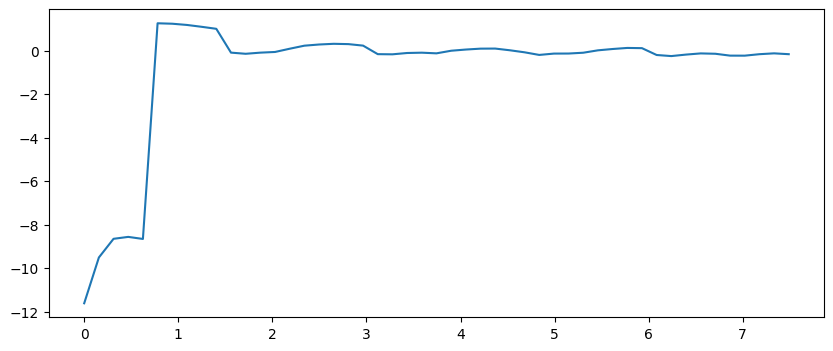

In [9]:

fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(111) 
ax.plot(tvec_sec[:-1]/3600, constr_ps0[:-1], color='C0', label='CVX')
ax.plot(tvec_sec[:-1]/3600, constr_ps1[:-1],  color='C1', label='SCP')
ax.hlines(0, tvec_sec[0]/3600, tvec_sec[-1]/3600, color='k', linestyle='--')
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Constraint violation ')
ax.set_ylim(-0.3, 1)
ax.legend()

print('max. constraint violation:', np.max(constr_ps0))
print('max. constraint violation:', np.max(constr_ps1))

In [ ]:
# including imperfect burns 
oe = propagate_oe(param.oec0, param.tvec_sec)
t_cvx_ct, roe_cvx_ct, rtn_cvx_ct = propagate_ct(roe_opt, uopt, oe, param.tvec_sec, n=20)
t_ps_ct, roe_ps_ct, rtn_ps_ct = propagate_ct(roe_scp, uopt_scp, oe, param.tvec_sec, n=20)

# for the imperfect-burn passive safety 
n_fail_mode = 10 
alpha = np.linspace(0, 1, n_fail_mode)
s_rtn_ps_imperfect = np.zeros((n_fail_mode, n_time, n_safe, 6))

for i in range(n_fail_mode):
    _, s_rtn_ps_imperfect[i], _, _, _, _ = prob.eval_ps(roe_scp, alpha[i] * uopt_scp, prob.tvec_sec, chance=False)

rtn_range_nom = np.linalg.norm(rtn_ps_ct[:, :3], axis=1)


In [ ]:
# plot helper for circle KOZ 
phi = np.linspace(0, 2*np.pi, 100)
x_circ = param.dim_koz[0][0] * np.cos(phi)
y_circ = param.dim_koz[0][0] * np.sin(phi)

fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(121)
ax1.scatter(rtn_opt[0, 1], rtn_opt[0,0], marker = 'o', color='r', edgecolor='k', zorder=20, label='$t_0$')
ax1.scatter(rtn_opt[-1, 1], rtn_opt[0,-1], marker = 'o', color='g', edgecolor='k',  zorder=20, label='$t_f$')
ax1.plot(rtn_cvx_ct[:,1], rtn_cvx_ct[:,0], color='k', linewidth=2, zorder=10, label='CVX')
ax1.quiver(rtn_opt[:,1], rtn_opt[:,0], -uopt[:,1], uopt[:,0], color="b", linewidth=2, scale=30)
ax1.plot(rtn_ps_ct[:,1], rtn_ps_ct[:,0], color='C1', linewidth=2, zorder=10, label='SCP')
ax1.quiver(rtn_opt_ps[:,1], rtn_opt_ps[:,0], -uopt_scp[:,1], uopt_scp[:,0], color="C2", linewidth=2, scale=20)
ax1.plot(x_circ, y_circ, color='r', linestyle='--', label='KOZ')
ax1.set_xlabel("$T$ [m]")
ax1.set_ylabel("$R$ [m]")
ax1.legend()
ax1.invert_xaxis()
ax1.grid()
ax1.axis('equal')
ax2 = fig.add_subplot(122)
ax2.scatter(rtn_opt[0,2], rtn_opt[0,0], marker = 'o', color='r', edgecolor='k', zorder=20, label='$t_0$')
ax2.scatter(rtn_opt[-1,2], rtn_opt[-1,0], marker = 'o', color='g', edgecolor='k',  zorder=20, label='$t_f$')
ax2.plot(rtn_cvx_ct[:,2], rtn_cvx_ct[:,0], color='k', linewidth=2, zorder=10, label='CVX')
ax2.quiver(rtn_opt_ps[:,2], rtn_opt_ps[:,0], uopt_scp[:,2], uopt_scp[:,0], color="b", linewidth=2, scale=20)
ax2.plot(rtn_ps_ct[:,2], rtn_ps_ct[:,0], color='C1', linewidth=2, zorder=10, label='SCP')
ax2.quiver(rtn_opt_ps[:,2], rtn_opt_ps[:,0], uopt_scp[:,2], uopt_scp[:,0], color="C2", linewidth=2, scale=20)
ax2.plot(x_circ, y_circ, color='r', linestyle='--', label='KOZ')
ax2.set_xlabel("$N$ [m]")
ax2.set_ylabel("$R$ [m]")
ax2.grid()
# ax2.axis("equal")
fig.tight_layout()


In [ ]:
# plot 
fig = plt.figure(figsize=(15, 4))
ax1 = fig.add_subplot(121)

cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, n_fail_mode))

ax1.plot(t_ps_ct / param.period, rtn_range_nom, color='C1', linewidth=1.5, zorder=7)
ax1.scatter(t_ps_ct[-1] / param.period, rtn_range_nom[-1], color='C1', s=15, zorder=7)
for i in range(prob.n_time-1):
    for k in range(n_fail_mode):
        color_k = colors[k]
        rtn_range_ps = np.linalg.norm(s_rtn_ps_imperfect[k, i, :, 0:3], axis=1)
        ax1.plot((prob.tvec_sec[i] + prob.tvec_safe_sec) / param.period, rtn_range_ps, color=color_k, alpha=1, linewidth=0.4, zorder=4)
        if k == n_fail_mode - 1:
            ax1.plot((prob.tvec_sec[i] + prob.tvec_safe_sec) / param.period, rtn_range_ps, color=color_k, alpha=1, linewidth=0.4, zorder=6)
        if k == 0:
            ax1.scatter(prob.tvec_sec[i] / param.period, rtn_range_ps[0], color="C1", s=15, zorder=7)
for r_koz in param.dim_koz:
    r_koz = r_koz[0]
    ax1.hlines(r_koz, 0, (prob.tvec_sec[-1] + prob.tvec_safe_sec[-1]) / param.period,
               color='0.6', linestyle='-.', label="KOZ radius") #label=f'{r_koz} m')

# legend and colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
cbar = fig.colorbar(sm, ax=ax1, fraction=0.046, pad=0.04)
cbar.set_label(r'$\alpha$')

ax1.scatter([], [], color='C1', label='control node')
ax1.plot([], [], color='C1', linewidth=2, label='nominal')
ax1.set_xlabel("time, orbit")
ax1.set_ylabel("range, m")
# ax1.set_yscale('log')
# ax1.set_ylim([-2+r_koz, 5+r_koz])
ax1.legend()

plt.savefig("figures/ps_ct_range.png", dpi=600, bbox_inches='tight')

In [ ]:
plot_3d = True
if plot_3d:
    
    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, projection='3d')
    
    phi = np.linspace(0, 2*np.pi, 100)
    x_circ = param.dim_koz[0][0] * np.cos(phi)
    y_circ = param.dim_koz[0][0] * np.sin(phi)
    
    ax.set_facecolor('white')
    ax.grid(False)
    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis.pane.fill = False
        axis.line.set_color('black')
        axis.line.set_linewidth(1)  # increase thickness
    
    ax.scatter(rtn_scp_ct[0,1], rtn_scp_ct[0,2], rtn_scp_ct[0,0], marker = 'o', color='r', edgecolor='k', zorder=20, label='Start')
    ax.scatter(rtn_scp_ct[-1,1], rtn_scp_ct[-1,2], rtn_scp_ct[-1,0], marker = 'o', color='g', edgecolor='k',  zorder=20, label='Goal')
    ax.plot(rtn_scp_ct[:,1], rtn_scp_ct[:,2], rtn_scp_ct[:,0], color='C1', linewidth=2, zorder=10, label='nominal')
    # ax.quiver(rtn_scp_ct[1,:], rtn_scp_ct[2,:], rtn_scp_ct[0,:], uopt[1,:], uopt[2,:],uopt[0,:], color="C2", length=500)
    
    x_scp, y_scp, z_scp = rtn_scp_ct[:,0], rtn_scp_ct[:,1], rtn_scp_ct[:,2]
    # minimal "projection shadows" onto planes
    alpha = 0.7
    R_proj = -90; T_proj = -200; N_proj = -150
    ax.plot(y_scp, z_scp, np.full_like(x_scp, R_proj), 'k-', alpha=alpha, linewidth=0.5)  # xy plane (RT)
    ax.plot(y_scp, np.full_like(z_scp, N_proj), x_scp, 'k-', alpha=alpha, linewidth=0.5)  # xz plane (RN)
    ax.plot(np.full_like(y_scp, T_proj), z_scp, x_scp, 'k-', alpha=alpha, linewidth=0.5)  # yz plane (TN)
        
    for i in range(n_time):
        for j in range(n_fail_mode):
            color_j = colors[j]
            ax.plot(s_rtn_ps_imperfect[j,i,:,1], s_rtn_ps_imperfect[j,i,:,2], s_rtn_ps_imperfect[j,i,:,0], color=color_j, alpha=0.7, linewidth=0.5)

    plot_ellipse(ax, np.array([param.dim_koz[0,1], param.dim_koz[0,2], param.dim_koz[0,0]]), pos=[0,0,0], Ndisc=20)

    # circle (kOZ) projection
    ax.plot(y_circ, x_circ, np.full_like(x_circ, R_proj), 'r-', alpha=alpha, linewidth=0.5)
    ax.plot(x_circ, np.full_like(x_circ, N_proj), y_circ, 'r-', alpha=alpha, linewidth=0.5)
    ax.plot(np.full_like(x_circ, T_proj), y_circ, x_circ, 'r-', alpha=alpha, linewidth=0.5)
    # ax.xaxis.set_major_formatter(m_formatter)
    # ax.yaxis.set_major_formatter(m_formatter)
    # ax.zaxis.set_major_formatter(m_formatter)
    ax.set_xlabel("$T$, m")
    ax.set_ylabel("$N$, m")
    ax.set_zlabel("$R$, m")
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.set_pane_color((1.0, 1.0, 1.0, 0))
    ax.view_init(elev=25, azim=70)
    ax.set_xlim([N_proj, 80])
    ax.axis("equal")
    ax.legend(bbox_to_anchor=(0.7, 0.85), loc='upper left')
fig.tight_layout()
plt.savefig("figures/ps_ct_traj.png", dpi=600, bbox_inches='tight')

In [ ]:
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(331)
ax1.plot(tvec_sec/period, roe_scp[:,0]) 
ax1.plot(tvec_sec/period, roe_opt[:,0], 'k--')
ax1.set_ylabel('$a\delta a$ [m]')
ax2 = fig.add_subplot(332)
ax2.plot(tvec_sec/period, roe_scp[:,1])
ax2.plot(tvec_sec/period, roe_opt[:,1], 'k--')
ax2.set_ylabel('$a\delta \lambda$[m]')
ax3 = fig.add_subplot(333)
ax3.plot(tvec_sec/period, roe_scp[:,2])
ax3.plot(tvec_sec/period, roe_opt[:,2], 'k--')
ax3.set_ylabel('$a\delta e_x$[m]')
ax4 = fig.add_subplot(334)
ax4.plot(tvec_sec/period, roe_scp[:,3])
ax4.plot(tvec_sec/period, roe_opt[:,3], 'k--')
ax4.set_ylabel('$a\delta e_y$[m]')
ax5 = fig.add_subplot(335)
ax5.plot(tvec_sec/period, roe_scp[:,4])
ax5.plot(tvec_sec/period, roe_opt[:,4], 'k--')
ax5.set_ylabel('$a\delta i_x$[m]')
ax6 = fig.add_subplot(336)
ax6.plot(tvec_sec/period, roe_scp[:,5])
ax6.plot(tvec_sec/period, roe_opt[:,5], 'k--')
ax6.set_ylabel('$a\delta i_y$[m]')
# control 
ax7 = fig.add_subplot(337)
ax7.stem(tvec_sec/period, uopt_scp[:,0], 'g')
ax7.set_ylabel('$\Delta v_R$ [m/s]')
ax7.set_xlabel('Time (orbits)')
ax8 = fig.add_subplot(338)
ax8.stem(tvec_sec/period, uopt_scp[:,1], 'g')
ax8.set_ylabel('$\Delta v_T$ [m/s]')
ax8.set_xlabel('Time (orbits)')
ax9 = fig.add_subplot(339)
ax9.stem(tvec_sec/period, uopt_scp[:,2], 'g')
ax9.set_ylabel('$\Delta v_N$ [m/s]')
ax9.set_xlabel('Time (orbits)')
fig.tight_layout()

In [ ]:
fig = plt.figure(figsize=(10, 6))
ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)  

ax1.plot(roe_scp[:,1], roe_scp[:,0])
ax1.plot(roe_opt[:,1], roe_opt[:,0], 'k--')
ax2.plot(roe_scp[:,2], roe_scp[:,3])
ax2.plot(roe_opt[:,2], roe_opt[:,3], 'k--')
ax3.plot(roe_scp[:,4], roe_scp[:,5])
ax3.plot(roe_opt[:,4], roe_opt[:,5], 'k--')

for i in range(len(wyp)):
    ax1.scatter(wyp[i][1], wyp[i][0], marker='x', color='r', s=100, label=f'waypoint {i}')
    ax2.scatter(wyp[i][2], wyp[i][3], marker='x', color='r', s=100)
    ax3.scatter(wyp[i][4], wyp[i][5], marker='x', color='r', s=100)

In [ ]:
# later work 

In [ ]:

phi = np.linspace(0, 2*np.pi, 100)
unit = np.vstack((np.cos(phi), np.sin(phi)))  

fig = plt.figure(figsize=(10,6))
ax1 = fig.add_subplot(221)
ax1.scatter(rtn_opt[1,0], rtn_opt[0,0], marker = 'o', color='r', edgecolor='k', zorder=20, label='$t_0$')
ax1.scatter(rtn_opt[1,-1], rtn_opt[0,-1], marker = 'o', color='g', edgecolor='k',  zorder=20, label='$t_f$')
# cvx
ax1.plot(rtn_opt[1,:], rtn_opt[0,:], color='k', linewidth=1, zorder=10, label='CVX')
ax1.quiver(rtn_opt[1,:], rtn_opt[0,:], -uopt[1,:], uopt[0,:], color="b", linewidth=1, scale=20)
# scp-ps
ax1.plot(rtn_opt_ps[1,:], rtn_opt_ps[0,:], color='r', linewidth=2, label='SCP-PS')

# scp-ps drift trajectories 
for i in range(n_time): 
    ax1.plot(s_rtn_ps1[1,i,:], s_rtn_ps1[0,i,:], color='green', linestyle='-.', linewidth=0.2)
    for j in range(n_safe): 
        Σ_rt  = Σ_rtn_ps1[:2, :2, i, j]
        c_rt = s_rtn_ps1[:2, i, j]
        vals, vecs = np.linalg.eigh(Σ_rt)
        radii = invICDF * np.sqrt(vals)  
        ell = vecs @ (radii[:, None] * unit) + c_rt[:, None]   # shape (2,100)
        plt.plot(ell[1], ell[0], '-', linewidth=0.2, color='k')

ax1.set_xlabel("$T$ [m]")
ax1.set_ylabel("$R$ [m]")
ax1.legend(loc="upper right")
ax1.invert_xaxis()
ax1.grid()

ax3 = fig.add_subplot(223)
ax3.scatter(rtn_opt[1,0], rtn_opt[0,0], marker = 'o', color='r', edgecolor='k', zorder=20)
ax3.scatter(rtn_opt[1,-1], rtn_opt[0,-1], marker = 'o', color='g', edgecolor='k',  zorder=20)
# cvx
ax3.plot(rtn_opt[1,:], rtn_opt[0,:], color='k', linewidth=1, zorder=10) 
ax3.quiver(rtn_opt[1,:], rtn_opt[0,:], uopt[1,:], uopt[0,:], color="b", linewidth=1, scale=20)
# scp-ps
ax3.plot(rtn_opt_ps[1,:], rtn_opt_ps[0,:], color='r', linewidth=2, )
ax3.scatter(rtn_opt_ps[1,-1], rtn_opt_ps[0,-1], marker = 'o', color='orange', edgecolor='k',  zorder=20)
# scp-ps drift trajectories
for i in range(n_time): 
    ax3.plot(s_rtn_ps1[1,i,:], s_rtn_ps1[0,i,:], color='green', linestyle='-.', linewidth=0.2)
    for j in range(n_safe): 
        Σ_rt  = Σ_rtn_ps1[:2, :2, i, j]
        c_rt = s_rtn_ps1[:2, i, j]
        vals, vecs = np.linalg.eigh(Σ_rt)
        radii = invICDF * np.sqrt(vals)  
        ell = vecs @ (radii[:, None] * unit) + c_rt[:, None]   # shape (2,100)
        plt.plot(ell[1], ell[0], '-', linewidth=0.2, color='k')
        
for k in range(dim_koz.shape[0]):
    ax3.plot(dim_koz[k,1]*np.cos(phi), dim_koz[k,0]*np.sin(phi), linestyle='-', linewidth=1, label='KOZ')
    
ax3.set_xlabel("$T$ [m]")
ax3.set_ylabel("$R$ [m]")
ax3.set_xlim([-7000, 7000])
ax3.set_ylim([-5000, 2000])
ax3.invert_xaxis()
ax3.grid()
ax3.legend(loc="upper right")


ax2 = fig.add_subplot(222)
ax2.scatter(rtn_opt[2,0], rtn_opt[0,0], marker = 'o', color='r', edgecolor='k', zorder=20, label='$t_0$')
ax2.scatter(rtn_opt[2,-1], rtn_opt[0,-1], marker = 'o', color='g', edgecolor='k',  zorder=20, label='$t_f$')
ax2.plot(rtn_opt[2,:], rtn_opt[0,:], color='k', linewidth=1, zorder=10)
ax2.quiver(rtn_opt[2,:], rtn_opt[0,:], uopt[2,:], uopt[0,:], color="b", linewidth=1, scale=20)
ax2.plot(rtn_opt_ps[2,:], rtn_opt_ps[0,:], color='r', linewidth=2, )
for i in range(n_time): 
    ax2.plot(s_rtn_ps1[2,i,:], s_rtn_ps1[0,i,:], color='green', linestyle='-.', linewidth=0.2)
    for j in range(n_safe):
        Σ_rt  = Σ_rtn_ps1[np.ix_([0,2], [0,2])][..., i, j]
        c_rt = s_rtn_ps1[[0,2], i, j]
        vals, vecs = np.linalg.eigh(Σ_rt)
        radii = invICDF * np.sqrt(vals)  
        ell = vecs @ (radii[:, None] * unit) + c_rt[:, None]
        plt.plot(ell[1], ell[0], '-', linewidth=0.2, color='k')
ax2.set_xlabel("$N$ [m]")
ax2.set_ylabel("$R$ [m]")
ax2.axis('equal')
ax2.grid()

ax4 = fig.add_subplot(224)
ax4.scatter(rtn_opt[2,0], rtn_opt[0,0], marker = 'o', color='r', edgecolor='k', zorder=20)
ax4.scatter(rtn_opt[2,-1], rtn_opt[0,-1], marker = 'o', color='g', edgecolor='k',  zorder=20)
ax4.plot(rtn_opt[2,:], rtn_opt[0,:], color='k', linewidth=1, zorder=10)
ax4.quiver(rtn_opt[2,:], rtn_opt[0,:], uopt[2,:], uopt[0,:], color="b", linewidth=1, scale=20)
ax4.plot(rtn_opt_ps[2,:], rtn_opt_ps[0,:], color='r', linewidth=2, )
for i in range(n_time): 
    ax4.plot(s_rtn_ps1[2,i,:], s_rtn_ps1[0,i,:], color='green', linestyle='-.', linewidth=0.2)
    for j in range(n_safe):
        Σ_rt  = Σ_rtn_ps1[np.ix_([0,2], [0,2])][..., i, j]
        c_rt = s_rtn_ps1[[0,2], i, j]
        vals, vecs = np.linalg.eigh(Σ_rt)
        radii = invICDF * np.sqrt(vals)  
        ell = vecs @ (radii[:, None] * unit) + c_rt[:, None]
        plt.plot(ell[1], ell[0], '-', linewidth=0.2, color='k')
        
for k in range(dim_koz.shape[0]):
    ax4.plot(dim_koz[k,2]*np.cos(phi), dim_koz[k,0]*np.sin(phi), linestyle='-', linewidth=1, label='KOZ')
    
ax4.set_xlabel("$N$ [m]")
ax4.set_ylabel("$R$ [m]")
ax4.set_xlim([-5000, 5000])
ax4.set_ylim([-3000, 3000])
ax4.grid()

fig.tight_layout()


In [ ]:
# problem.n_obj = 2 

rtg_cvx = problem.compute_rtg(sol["actions"].T)
ctg_cvx, _ = problem.compute_ctg(sol["states"].T, sol["actions"].T)
rtg_scp = problem.compute_rtg(sol_ps["actions"].T)
ctg_scp, _  = problem.compute_ctg(sol_ps["states"].T, sol_ps["actions"].T)

In [ ]:
fig = plt.figure(figsize=(10,4))
ax1 = fig.add_subplot(121)
ax1.plot(np.arange(n_time), rtg_scp[:,0], color='C0', label="Time-to-go (SCP)")
ax1.plot(np.arange(n_time), rtg_scp[:,1], color='C1', label="Cost-to-go (SCP)")
ax1.plot(np.arange(n_time), rtg_cvx[:,0], 'k--', label="Time-to-go (CVX)")
ax1.plot(np.arange(n_time), rtg_cvx[:,1], 'k:', label="Cost-to-go (CVX)")
ax1.set_ylabel("RTG")
ax1.set_xlabel("Time step")
ax1.legend()
ax2 = fig.add_subplot(122)
ax2.plot(np.arange(n_time), ctg_scp.flatten(), color='C2', label="CTG (SCP)")
ax2.plot(np.arange(n_time), ctg_cvx.flatten(), 'k--', label="CTG (CVX)")
ax2.legend()
ax2.set_ylabel("CTG")
ax2.set_xlabel("Time step")
fig.tight_layout()

In [ ]:
sol_ps["actions"]

In [ ]:
prob.convexified_problem = True

In [ ]:
# Now solve with SCP
sol, log = solve_scp_ocp(prob=prob)
print(f"SCP solution status: {log['status']}")
print(f"SCP solution cost: {log['cost']:.3f} m/s")
print(f"SCP iterations: {log['iterations']}")

In [ ]:
# for loop 

for i in range(50): 
    # sample reset condition
    behavior_mode, roe0, roef, t_idx_wyp = sample_reset_condition()
    
    # Generate time vector and compute dt_sec from it
    tvec_sec = np.linspace(0, tf_sec, n_time_rpod)
    dt_sec = tvec_sec[1] - tvec_sec[0]  # Compute dt from the generated time vector
    
    # Ensure DEED is the right size for this problem
    import rpod.optimization.parameters as param
    from rpod.optimization.rpod_scenario import DEED_koz
    param.DEED = np.tile(DEED_koz[:, :, np.newaxis], (1, 1, n_time_rpod))

    obs0 = {
        'time' : 0.0,
        'state' : roe0,
        'goal' : roef,
        'dv' : np.zeros(1),
        'ttg' : tf_sec,
        'dt' : dt_sec,
        'observation' : None,
        'oe': oe_0_ref,  # Should be 1D array, not reshaped
    }

    problem = NonConvexOCP(
        prob_definition={
            't_i' : 0,
            't_f' : n_time_rpod,
            'tvec_sec' : tvec_sec,
            'chance' : True,
            'current_obs' : obs0,
            'local_state_goal' : None,
            'hardness' : False,
            'convexified_problem' : True,
            'verbose' : False,
            'state_def' : 'eroe'  # Add state_def if needed
        }, 
    )
    
    sol, log = solve_scp_ocp(prob=problem)
    roe_opt = sol["states"]
    uopt = sol["actions"]
    
    # Use problem.oe (orbital elements history from the problem) instead of oec
    rtn_opt = problem.f_2rtn(roe_opt, problem.oe)
    cost = np.sum(np.linalg.norm(uopt, axis=0)) 
    print(f"Final cost: {cost:.3f} m/s")
    s_roe_ps0, s_rtn_ps0, Σ_roe_ps0, Σ_rtn_ps0, _, constr_ps0 = problem.eval_ps(sol["states"], sol["actions"], prob.tvec_sec, chance=True)   
    
    problem.convexified_problem = False
    problem.verbose_scvx = False
    problem.verbose = False
    problem.zref = {'state' : roe_opt, 'action' : uopt}
    problem.sol_0 = {"z": problem.zref}
    problem.generate_scaling(roe_opt, uopt)

    sol_ps, log = solve_scp_ocp(prob=problem)
    roe_opt_ps = sol_ps["states"]
    uopt_ps = sol_ps["actions"]
    print("scp status:", log["status"])
    
    # Use problem.oe instead of oec
    rtn_opt_ps = problem.f_2rtn(roe_opt_ps, problem.oe)
    s_roe_ps1, s_rtn_ps1, Σ_roe_ps1, Σ_rtn_ps1, _, constr_ps1  = problem.eval_ps(sol_ps["states"], sol_ps["actions"], prob.tvec_sec, chance=True)   
    cost_ps = np.sum(np.linalg.norm(uopt_ps, axis=0)) 
    print(f"Final cost: {cost_ps:.3f} m/s")
    # print(constr_ps1)
